In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 

In [35]:
cols = ["engine_id", "cycle", "op_setting_1","op_setting_2", "op_setting_3"]

for i in range(22):
    cols.append(f"sensor_{i}")

In [36]:
print(len(cols))

27


In [17]:
import os

print("Current Directory:")
print(os.getcwd())

print("\nFiles/Folders Here:")
print(os.listdir())

print("\nPath Exists?")
print(os.path.exists(r"..\data\train_FD001.txt"))

Current Directory:
c:\Desktop\github_projects\Predictive maintainance\eda

Files/Folders Here:
['eda.ipynb']

Path Exists?
True


In [29]:
import os

print(os.path.exists(r"..\data\train_FD001.txt"))

True


In [39]:
train = pd.read_csv(r"..\data\train_FD001.txt",sep=r"\s+",header=None)
print(train.shape)
print(len(cols))
train.columns = cols

(20631, 26)
26


In [40]:
train.shape

train.head()

train.info()

train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   engine_id     20631 non-null  int64  
 1   cycle         20631 non-null  int64  
 2   op_setting_1  20631 non-null  float64
 3   op_setting_2  20631 non-null  float64
 4   op_setting_3  20631 non-null  float64
 5   sensor_1      20631 non-null  float64
 6   sensor_2      20631 non-null  float64
 7   sensor_3      20631 non-null  float64
 8   sensor_4      20631 non-null  float64
 9   sensor_5      20631 non-null  float64
 10  sensor_6      20631 non-null  float64
 11  sensor_7      20631 non-null  float64
 12  sensor_8      20631 non-null  float64
 13  sensor_9      20631 non-null  float64
 14  sensor_10     20631 non-null  float64
 15  sensor_11     20631 non-null  float64
 16  sensor_12     20631 non-null  float64
 17  sensor_13     20631 non-null  float64
 18  sensor_14     20631 non-nu

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,1.776400e-15,...,0.737553,0.071919,19.076176,0.037505,1.387812e-17,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


### no of engines

In [41]:
train['engine_id'].nunique()

100

In [42]:
# cycles per engine 

engine_life = train.groupby('engine_id')['cycle'].max()
engine_life.describe()

count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64

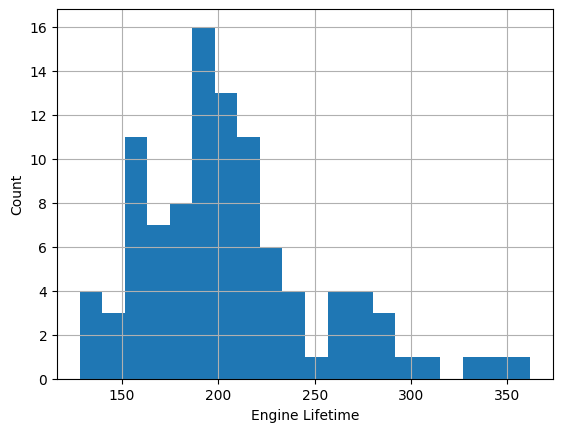

In [43]:
import matplotlib.pyplot as plt

engine_life.hist(bins=20)
plt.xlabel("Engine Lifetime")
plt.ylabel("Count")
plt.show()

In [46]:
max_cycles = train.groupby('engine_id')['cycle'].max()
train['max_cycle'] = train['engine_id'].map(max_cycles)
train['RUL'] = train['engine_id'].map(max_cycles)

In [47]:
train[['engine_id','cycle','RUL']].head()

,engine_id,cycle,RUL
0,1,1,192
1,1,2,192
2,1,3,192
3,1,4,192
4,1,5,192


In [48]:
train.isnull().sum()

engine_id       0
cycle           0
op_setting_1    0
op_setting_2    0
op_setting_3    0
sensor_1        0
sensor_2        0
sensor_3        0
sensor_4        0
sensor_5        0
sensor_6        0
sensor_7        0
sensor_8        0
sensor_9        0
sensor_10       0
sensor_11       0
sensor_12       0
sensor_13       0
sensor_14       0
sensor_15       0
sensor_16       0
sensor_17       0
sensor_18       0
sensor_19       0
sensor_20       0
sensor_21       0
max_cycle       0
RUL             0
dtype: int64

<Axes: >

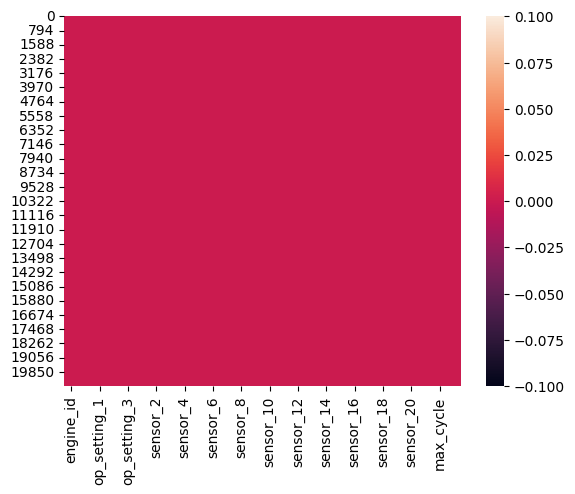

In [49]:
sns.heatmap(train.isnull())

In [ ]:
# Detect Constant Sensors

In [50]:
train.nunique()

engine_id        100
cycle            362
op_setting_1     158
op_setting_2      13
op_setting_3       1
sensor_1           1
sensor_2         310
sensor_3        3012
sensor_4        4051
sensor_5           1
sensor_6           2
sensor_7         513
sensor_8          53
sensor_9        6403
sensor_10          1
sensor_11        159
sensor_12        427
sensor_13         56
sensor_14       6078
sensor_15       1918
sensor_16          1
sensor_17         13
sensor_18          1
sensor_19          1
sensor_20        120
sensor_21       4745
max_cycle         66
RUL               66
dtype: int64

In [51]:
train.var(numeric_only=True)

engine_id       8.542545e+02
cycle           4.744591e+03
op_setting_1    4.784340e-06
op_setting_2    8.588541e-08
op_setting_3    0.000000e+00
sensor_1        0.000000e+00
sensor_2        2.500533e-01
sensor_3        3.759099e+01
sensor_4        8.101089e+01
sensor_5        3.155597e-30
sensor_6        1.929279e-06
sensor_7        7.833883e-01
sensor_8        5.038938e-03
sensor_9        4.876536e+02
sensor_10       0.000000e+00
sensor_11       7.133568e-02
sensor_12       5.439850e-01
sensor_13       5.172330e-03
sensor_14       3.639005e+02
sensor_15       1.406628e-03
sensor_16       1.926023e-34
sensor_17       2.398667e+00
sensor_18       0.000000e+00
sensor_19       0.000000e+00
sensor_20       3.266927e-02
sensor_21       1.171825e-02
max_cycle       2.502861e+03
RUL             2.502861e+03
dtype: float64